In [35]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

import ipaddress
import warnings
warnings.filterwarnings('ignore')

from collections import Counter


In [36]:
fraud_df = pd.read_csv('../data/Fraud_Data.csv')
ip_df = pd.read_csv('../data/IpAddress_to_Country.csv')
creditcard_df = pd.read_csv('../data/creditcard.csv')


In [37]:
print(fraud_df.isnull().sum())
print(creditcard_df.isnull().sum())

user_id           0
signup_time       0
purchase_time     0
purchase_value    0
device_id         0
source            0
browser           0
sex               0
age               0
ip_address        0
class             0
dtype: int64
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


In [38]:
fraud_df.dropna(inplace=True)
creditcard_df.dropna(inplace=True)

In [39]:
fraud_df.drop_duplicates(inplace=True)
creditcard_df.drop_duplicates(inplace=True)

In [40]:
fraud_df['signup_time'] = pd.to_datetime(fraud_df['signup_time'])
fraud_df['purchase_time'] = pd.to_datetime(fraud_df['purchase_time'])

Text(0.5, 1.0, 'Class Distribution in Fraud Data')

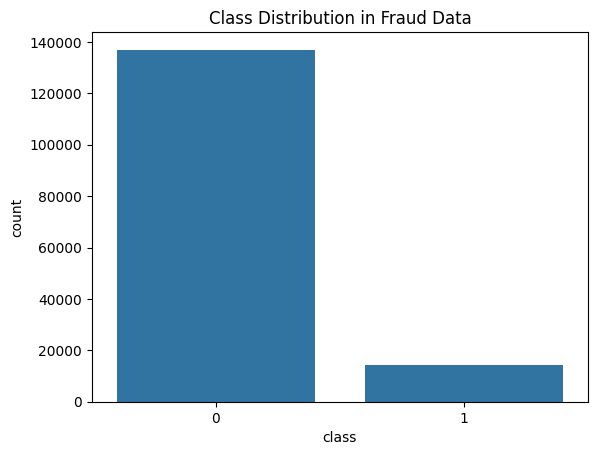

In [41]:
sns.countplot(data=fraud_df, x='class')
plt.title("Class Distribution in Fraud Data")

Text(0.5, 1.0, 'Purchase Value Distribution')

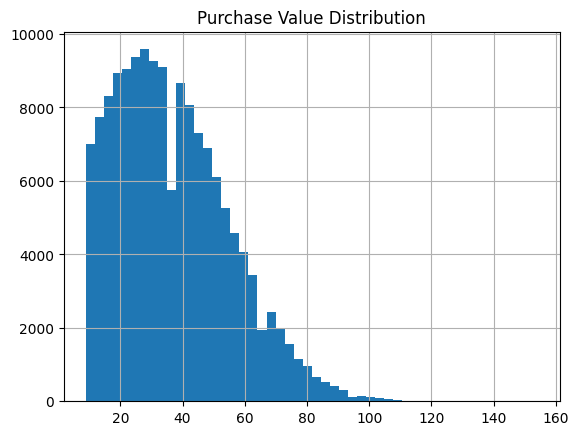

In [42]:
fraud_df['purchase_value'].hist(bins=50)
plt.title("Purchase Value Distribution")

<Axes: xlabel='class', ylabel='purchase_value'>

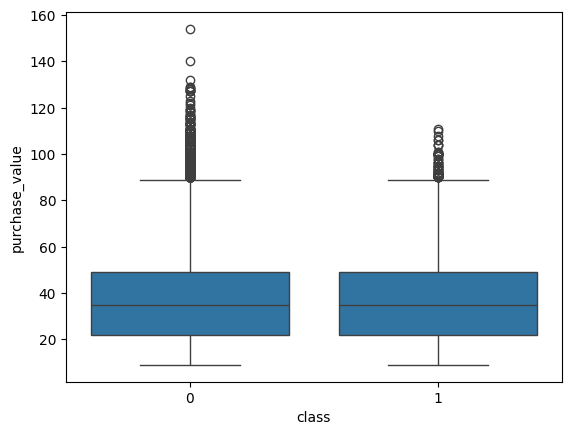

In [43]:
sns.boxplot(x='class', y='purchase_value', data=fraud_df)

In [44]:
fraud_df['ip_address'].head(10)

0    7.327584e+08
1    3.503114e+08
2    2.621474e+09
3    3.840542e+09
4    4.155831e+08
5    2.809315e+09
6    3.987484e+09
7    1.692459e+09
8    3.719094e+09
9    3.416747e+08
Name: ip_address, dtype: float64

In [45]:
fraud_df['ip_int'] = fraud_df['ip_address'].astype(int)

In [46]:
ip_df['lower_bound_ip_address'] = ip_df['lower_bound_ip_address'].astype(int)
ip_df['upper_bound_ip_address'] = ip_df['upper_bound_ip_address'].astype(int)

In [47]:
def find_country(ip):
    row = ip_df[(ip_df['lower_bound_ip_address'].astype(int) <= ip) & 
                (ip_df['upper_bound_ip_address'].astype(int) >= ip)]
    return row['country'].values[0] if not row.empty else 'Unknown'

fraud_df['country'] = fraud_df['ip_int'].apply(find_country)


In [48]:
fraud_df['hour_of_day'] = fraud_df['purchase_time'].dt.hour
fraud_df['day_of_week'] = fraud_df['purchase_time'].dt.dayofweek
fraud_df['time_since_signup'] = (fraud_df['purchase_time'] - fraud_df['signup_time']).dt.total_seconds() / 3600  # in hours

In [49]:
transaction_freq = fraud_df.groupby('user_id').size()
fraud_df['user_transaction_count'] = fraud_df['user_id'].map(transaction_freq)

In [50]:
print("Before SMOTE:", Counter(fraud_df['class']))

Before SMOTE: Counter({0: 136961, 1: 14151})


In [51]:
encoded_fraud = pd.get_dummies(fraud_df[['source', 'browser', 'sex', 'country']], drop_first=True)
features = pd.concat([fraud_df[['purchase_value', 'hour_of_day', 'day_of_week', 'time_since_signup', 'user_transaction_count']], encoded_fraud], axis=1)
target = fraud_df['class']

In [52]:
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(features, target)

print("After SMOTE:", Counter(y_resampled))

After SMOTE: Counter({0: 136961, 1: 136961})


In [53]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_resampled)